# Joint SSMT — Trial-Structured Quickstart

This notebook demonstrates the **trial-structured (hierarchical)** inference pipeline.

Use this when your recording contains **multiple trials** of the same condition. The model decomposes
spectral dynamics into a **shared** component (common across trials) and **trial-specific** deviations.

1. **Simulate** multi-trial LFP + spike data
2. **Run hierarchical inference**
3. **Interpret core results** — coupling heatmaps, trial-averaged dynamics
4. *(Optional)* Additional diagnostic plots

### Data format
- `lfp`: shape `(R, T)` — one LFP trace per trial
- `spikes`: shape `(R, S, T_fine)` — spike trains per trial per unit

In [ ]:
# If you haven't installed the package yet, uncomment and run:
# !pip install -e ..

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from joint_ssmt.io import run_inference_trials, load_results_trials

---
## 1. Simulate Trial-Structured Data

We use the trial simulator (in `manuscript_figures/trial_structure/`) that generates
multi-trial data with shared OU latents plus trial-specific deviations.

> **For real data** you would skip this and load your own `lfp` array of shape `(R, T)` and
> `spikes` array of shape `(R, S, T_fine)`.

In [17]:
# Add the trial simulator to path
sys.path.insert(0, '../manuscript_figures/trial_structure')
from simulate_trial_data import TrialSimConfig, simulate_trials

cfg = TrialSimConfig(
    R=20,                   # 20 trials (use >=50 for real analyses)
    S=3,                    # 3 spike units
    k_active=2,             # each unit couples to 2 of 4 couplable bands
    duration_sec=5.0,       # 5 s per trial
    b0_mu=-3.0,             # baseline firing rate
)

sim = simulate_trials(cfg, seed=42)

lfp    = sim['LFP']        # (R, T)
spikes = sim['spikes']     # (R, S, T_fine)
fs     = cfg.fs

R, T = lfp.shape
_, S, T_fine = spikes.shape

print(f"LFP shape:    {lfp.shape}   (R={R} trials, T={T} samples)")
print(f"Spikes shape: {spikes.shape} (S={S} units)")
print(f"\nCouplable frequencies: {sim['freqs_hz_coupled']}")
print(f"Signal-only frequencies: {sim['freqs_hz_extra']}")
print(f"\nCoupling mask (rows=units, cols=all signal bands):")
print(sim['masks'])

Simulation setup:
  Trials: R=20, Units: S=3
  Coupled signal bands (Jc=4): [11. 19. 27. 43.]
  Extra uncoupled signal bands (Ju=2): [ 7. 35.]
  Total signal bands (J=6): [11. 19. 27. 43.  7. 35.]
  LFP: T=5000 samples at fs=1000.0 Hz
  Spikes: T_fine=5000 samples at 1000.0 Hz
  b0_mu=-3.0 (baseline firing rate parameter)
  Dense frequency grid: F=60 frequencies (1 to 60 Hz)
  Signal frequency indices in dense grid: [ 6 10 18 26 34 42]
Generating shared OU processes...
Generating trial-specific OU deltas...
Computing derotated latents for spike predictors...
Generating coupling parameters...
  beta_true shape: (3, 13)
  masks shape: (3, 6)
Generating spikes...
  Spikes per unit: [3284 2840 2071]
  Mean firing rate: 27.32 Hz
Generating LFP with broadband noise...
Simulation complete.
LFP shape:    (20, 5000)   (R=20 trials, T=5000 samples)
Spikes shape: (20, 3, 5000) (S=3 units)

Couplable frequencies: [11. 19. 27. 43.]
Signal-only frequencies: [ 7. 35.]

Coupling mask (rows=units, cols

---
## 2. Run Hierarchical Inference

The trial-structured runner uses shorter time windows (`window_sec=0.4`) and coarser frequency grids (`freq_step=2`) since each trial is short.

> **Timing:** ~2–5 min for 10 trials × 5 s with these settings. For publication, use `warmup_iterations=1000`, `n_refresh_cycles=5`.

In [18]:
saved = run_inference_trials(
    lfp=lfp,
    spikes=spikes,
    spectral_config={
        'freq_min': 1.0,
        'freq_max': 61.0,
        'freq_step': 2.0,       # coarser grid for short trials
        'window_sec': 0.4,      # shorter window for trial data
        'time_bandwidth': 1.0,  # NW=1 (fewer tapers for short windows)
    },
    inference_config={
        'warmup_iterations': 200,
        'n_refresh_cycles': 2,
        'iterations_per_refresh': 50,
        'use_shrinkage': False,
        'wald_alpha': 0.05,
    },
    output_config={
        'output_dir': './results_trials',
        'save_spectral': True,
        'downsample_factor': 10,
    },
    fs=fs,
    plot=False,
)

print("Saved files:")
for k, v in saved.items():
    print(f"  {k}: {v}")

[EM-CT-HIER-JAX] iter 0  Q=-3.298620e+04
[EM-CT-HIER-JAX] iter 1000  Q=-2.595416e+04


Warmup (trial PG-Gibbs): 100%|██████████| 200/200 [03:11<00:00,  1.04it/s]
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_trials.py:919: RuntimeWarning: divide by zero encountered in matmul
  Sg = (ctr.T @ ctr) / max(gh.shape[0] - 1, 1)
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_trials.py:919: RuntimeWarning: overflow encountered in matmul
  Sg = (ctr.T @ ctr) / max(gh.shape[0] - 1, 1)
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_trials.py:919: RuntimeWarning: invalid value encountered in matmul
  Sg = (ctr.T @ ctr) / max(gh.shape[0] - 1, 1)
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_trials.py:1204: RuntimeWarning: divide by zero encountered in matmul
  Sg = (ctr.T @ ctr) / max(gh.shape[0] - 1, 1)
/Users/bowenzheng-millerlab/joint_ssmt/joint-ssmt/joint_ssmt/run_joint_inference_trials.py:1204: RuntimeWarning: overflow encountered in matmul
  S

[EM-CT-HIER-JAX] iter 0  Q=-3.298620e+04
Saved files:
  coupling: ./results_trials/coupling.npz
  spectral: ./results_trials/spectral.npz
  lfp_only: ./results_trials/ctssmt_lfp_only.npz
  metadata: ./results_trials/metadata.json


---
## 3. Core Results

In [19]:
results = load_results_trials('./results_trials')

coupling = results['coupling']
freqs    = coupling['freqs']
beta_mag = coupling['beta_mag']

S, J = beta_mag.shape
print(f"Frequency grid: {J} bands from {freqs[0]:.0f} to {freqs[-1]:.0f} Hz")
print(f"Units: {S}, Trials: {results['metadata']['data']['n_trials']}")

Frequency grid: 30 bands from 1 to 59 Hz
Units: 3, Trials: 20


### 3a. Coupling Detection Heatmap

Same interpretation as single-trial: left panel shows effect size, right panel shows $-\log_{10}(p)$ from the Wald test.

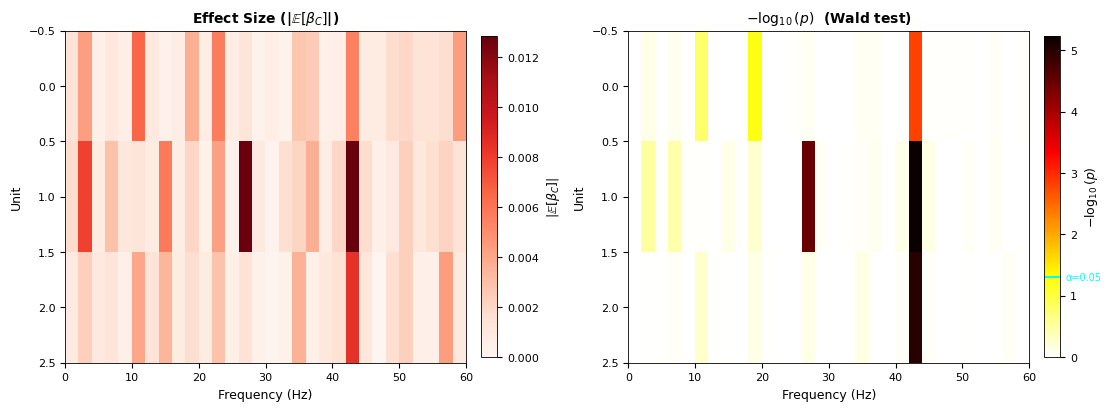

In [20]:
from joint_ssmt.plotting.summary import plot_coupling_summary

fig = plot_coupling_summary(results, effect_type='wald', alpha=0.05, figsize=(11, 4))
plt.show()

### 3b. Significant Coupling Pairs

In [21]:
wald_pval = coupling['wald_pval']
wald_W    = coupling['wald_W']
alpha = 0.05

print(f"Significant coupling pairs (alpha = {alpha}):\n")
print(f"  {'Unit':>4}  {'Freq (Hz)':>10}  {'|beta|':>8}  {'Wald W':>8}  {'p-value':>10}")
print("  " + "-" * 50)

for s in range(S):
    for j in range(J):
        if wald_pval[s, j] < alpha:
            print(f"  {s:>4}  {freqs[j]:>10.0f}  {beta_mag[s, j]:>8.4f}  "
                  f"{wald_W[s, j]:>8.2f}  {wald_pval[s, j]:>10.2e}")

Significant coupling pairs (alpha = 0.05):

  Unit   Freq (Hz)    |beta|    Wald W     p-value
  --------------------------------------------------
     0          43    0.0055     12.88    1.59e-03
     1          27    0.0127     20.61    3.34e-05
     1          43    0.0139     33.15    6.32e-08
     2          43    0.0084     22.94    1.04e-05


### 3c. Trial-Averaged Dynamics

For trial-structured data, the model separates **shared** spectral dynamics (orange line)
from **trial-specific** deviations (gray lines). This shows how oscillatory power at each
frequency evolves within a trial, averaged across trials.

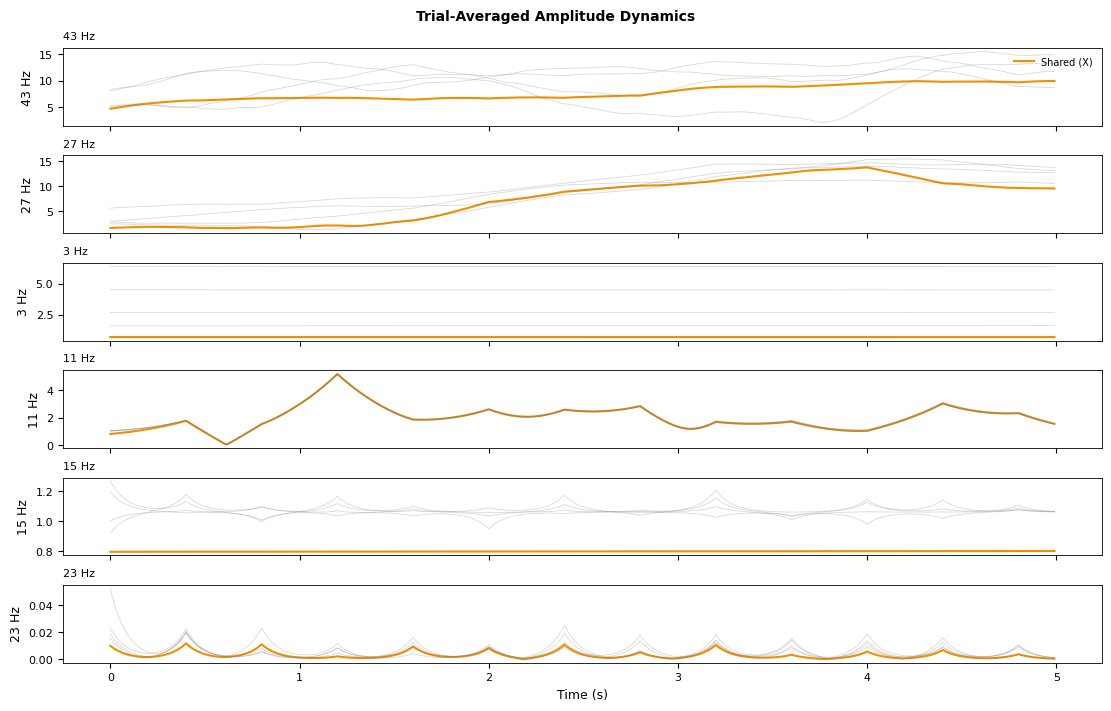

In [22]:
from joint_ssmt.plotting.summary import plot_trial_averaged_dynamics

try:
    fig = plot_trial_averaged_dynamics(results, n_freqs_to_show=6, figsize=(11, 7))
    plt.show()
except ValueError as e:
    print(f"Trial dynamics not available: {e}")
    print("(This requires save_spectral=True in output_config)")

### 3d. Spectrogram

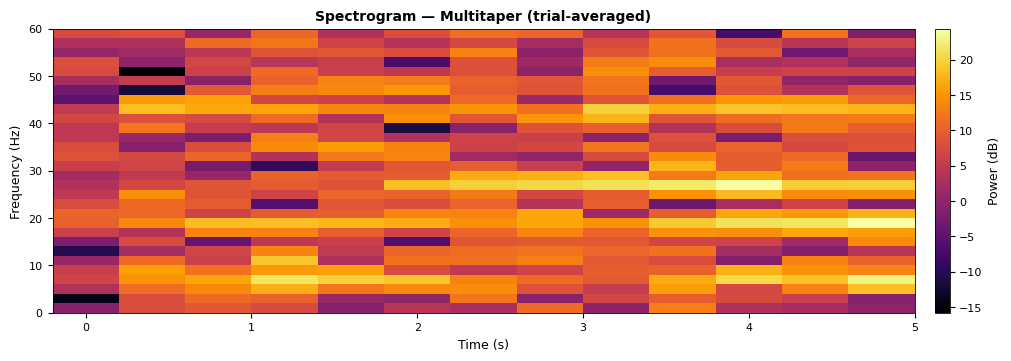

In [23]:
from joint_ssmt.plotting.summary import plot_spectrogram

fig = plot_spectrogram(results, method='multitaper', figsize=(10, 3.5))
plt.show()

### 3e. Run Metadata

In [24]:
meta = results['metadata']
print(f"Trials:            {meta['data']['n_trials']}")
print(f"Elapsed time:      {meta['timing']['elapsed_seconds']:.1f} s")
print(f"MCMC samples:      {meta['mcmc']['n_samples']}")
print(f"Significant bands: {meta['detection']['n_significant_bands']}")

Trials:            20
Elapsed time:      302.5 s
MCMC samples:      150
Significant bands: 2


---
## 4. Additional Plots (Optional)

These are useful for deeper analysis.

### 4a. Ground-Truth Comparison (simulation only)

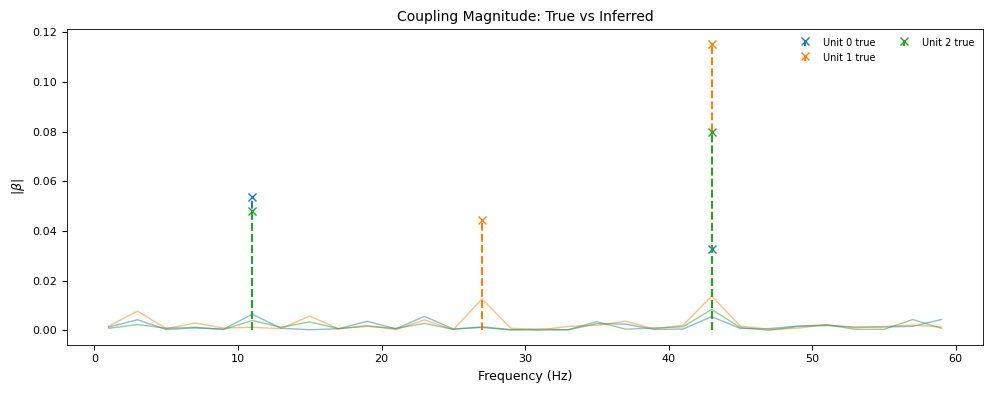

In [25]:
gt_mag      = sim['beta_mag']
gt_freqs    = sim['freqs_hz']
masks       = sim['masks']
freqs_coupled = sim['freqs_hz_coupled']
Jc = len(freqs_coupled)

# Map ground-truth frequencies to analysis grid
idx_map_coupled = [np.argmin(np.abs(freqs - f)) for f in freqs_coupled]

fig, ax = plt.subplots(figsize=(10, 4))
for s in range(S):
    coupled = masks[s, :Jc]
    ax.stem(
        freqs_coupled[coupled], gt_mag[s, :Jc][coupled],
        linefmt=f'C{s}--', markerfmt=f'C{s}x', basefmt=' ',
        label=f'Unit {s} true',
    )
    ax.plot(freqs, beta_mag[s], '-', color=f'C{s}', alpha=0.5, lw=1)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'$|\beta|$')
ax.set_title('Coupling Magnitude: True vs Inferred')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

### 4b. Beta Posterior Scatter

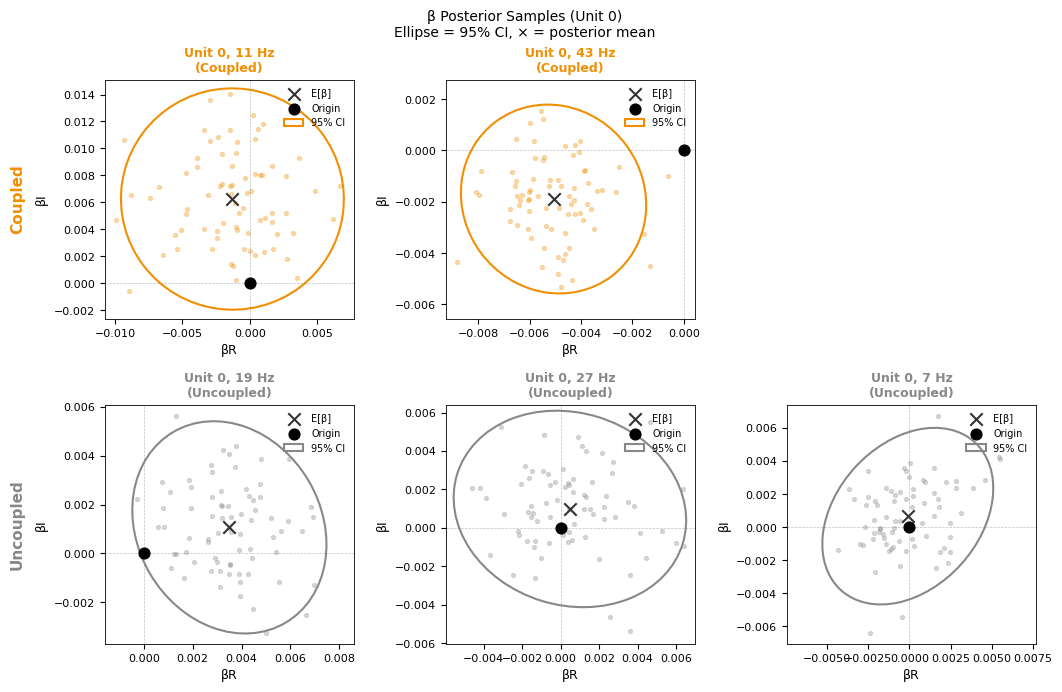

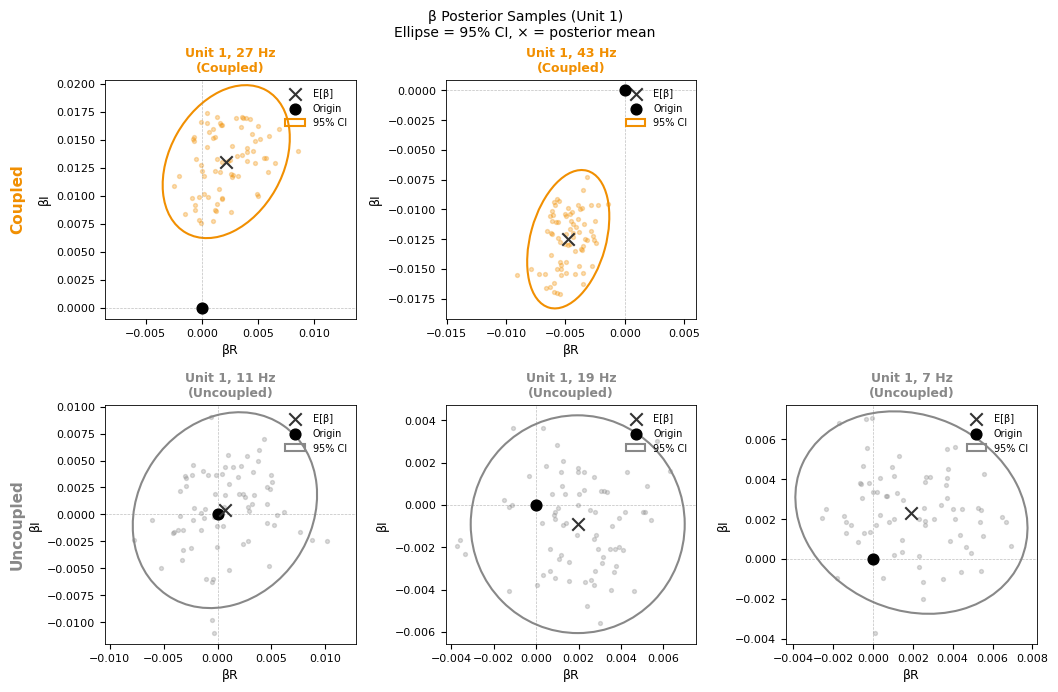

In [26]:
from joint_ssmt.plotting.beta_posterior import plot_beta_posterior_scatter

for s in range(min(S, 2)):  # first two units
    fig = plot_beta_posterior_scatter(
        coupling['beta_trace'],
        freqs,
        None,
        unit_idx=s,
        burn_in_frac=0.5,
        freqs_true=gt_freqs,
        masks=masks,
    )
    plt.show()

### 4c. Detailed Heatmaps

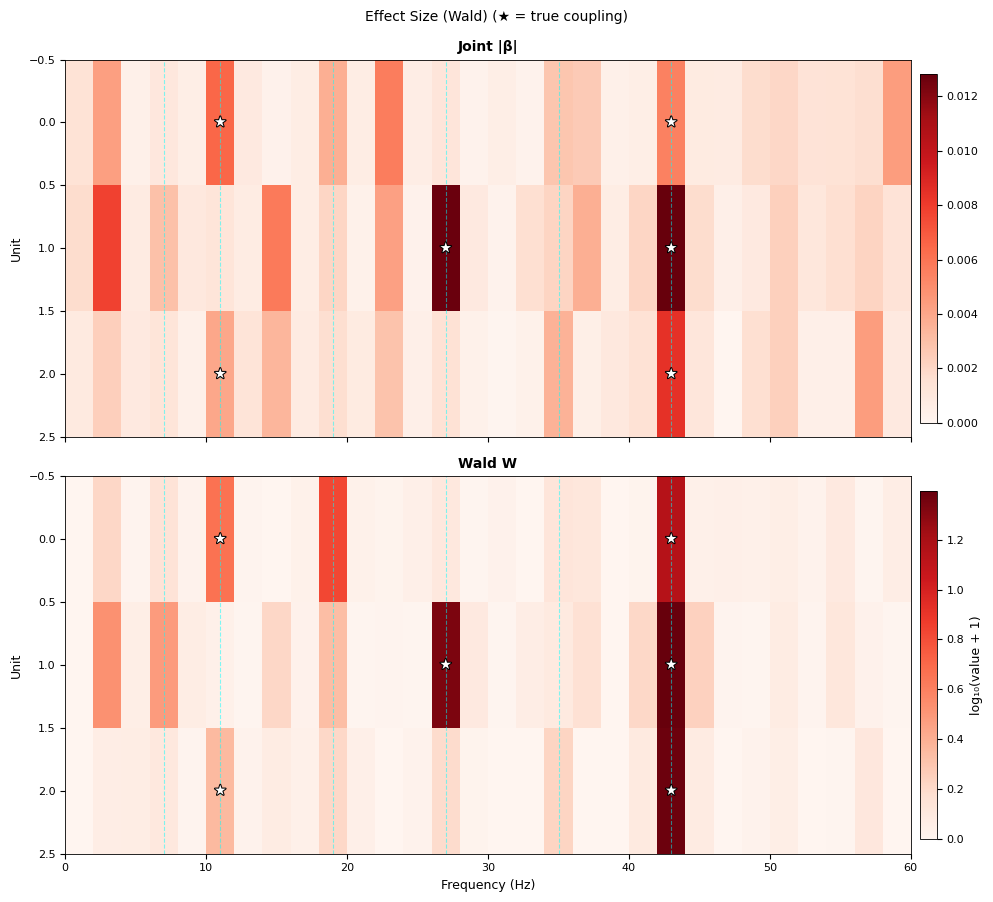

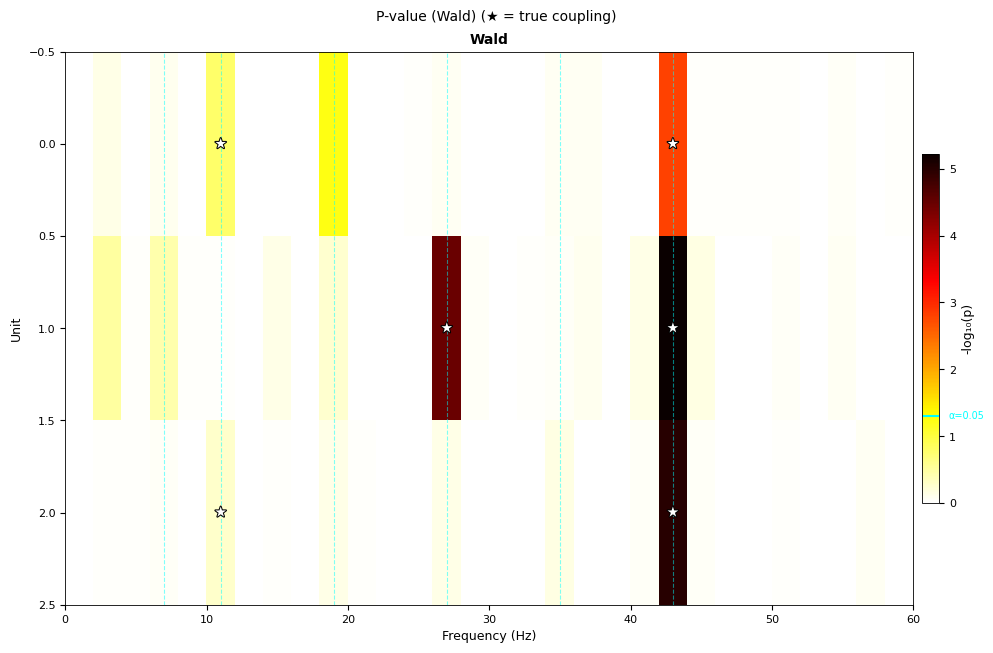

In [27]:
from joint_ssmt.plotting.heatmaps import (
    set_publication_style,
    plot_effect_comparison,
    plot_pval_comparison,
)

set_publication_style()

plot_effect_comparison(
    {'Joint |\u03b2|': beta_mag, 'Wald W': coupling['wald_W']},
    freqs, None,
    true_freqs=gt_freqs, masks=masks,
    log_scale_keys=('Wald W',),
    suptitle='Effect Size (Wald)',
)
plt.show()

plot_pval_comparison(
    {'Wald': coupling['wald_pval']},
    freqs, None,
    true_freqs=gt_freqs, masks=masks,
    alpha=0.05, suptitle='P-value (Wald)',
)
plt.show()

### 4d. Detailed Spectral Dynamics (simulation only)

These figures compare multitaper and joint estimates at the trial level,
including shared vs deviation components.

In [28]:
import os
from joint_ssmt.io import results_to_legacy_dict_trials

try:
    from joint_ssmt.plotting.spectral_dynamics_trials import generate_trial_dynamics_figures

    legacy = results_to_legacy_dict_trials('./results_trials')
    dynamics_dir = './results_trials/dynamics'
    os.makedirs(dynamics_dir, exist_ok=True)

    joint_results = {
        'trace': legacy['trace'],
        'freqs_dense': freqs,
    }

    generate_trial_dynamics_figures(
        sim_data=sim,
        joint_results=joint_results,
        lfp_results=None,
        output_dir=dynamics_dir,
        freqs_dense=freqs,
        sample_trials=list(range(min(4, R))),
        time_range=(0.5, 4.0),
    )
    print(f"Saved to {dynamics_dir}/")
except Exception as e:
    print(f"Spectral dynamics plots not available: {e}")

GENERATING TRIAL DYNAMICS FIGURES
  Using ground truth frequencies: [11. 19. 27. 43.  7. 35.]
  R=20 trials, T=5000 time points, J=30 freqs
  Frequencies to plot: [11. 19. 27. 43.  7. 35.]
  Plot freq -> dense idx: {np.float64(11.0): 5, np.float64(19.0): 9, np.float64(27.0): 13, np.float64(43.0): 21, np.float64(7.0): 3, np.float64(35.0): 17}
  Ground truth: (20, 30, 5000) (BASEBAND)
  Computing multitaper...
  Z_mt: (20, 30, 5000)
  CT-SSMT (LFP-only): NOT AVAILABLE
  Using X_fine_final + D_fine_final (BASEBAND, no derotation needed)
    X_fine: (500, 60), D_fine: (20, 500, 60)
  Z_spk (Joint from X+D): (20, 30, 5000)
  Z_lfp (LFP-only from X): (20, 30, 5000)
  Z_spk_var (posterior variance): (20, 30, 5000)
  Global scales: MT=0.0404, LFP=1.0000, Joint=0.6445

  Generating figures...
    [1/9] trial_specific_comparison
    [2/9] deviation_comparison
    [3/9] trial_averaged_comparison
    [4/9] spectrogram_trial_specific
    [5/9] spectrogram_trial_averaged
    [6/9] spectrogram_deviat